# 4 反向传播算法

学习目标

- 知道梯度下降算法
- 知道链式法则
- 掌握方向传播算法

多层神经网络的学习能力比单层网络强得多。想要训练多层网络，需要更强大的学习算法。误差反向传播算法（Back Propagation）是其中最杰出的代表，它是目前最成功的神经网络学习算法。现实任务使用神经网络时，大多是在使用 BP 算法进行训练，值得指出的是 BP 算法不仅可用于多层前馈神经网络，还可以用于其他类型的神经网络。通常说 BP 网络时，一般是指用 BP 算法训练的多层前馈神经网络。

这就需要了解两个概念：1. 正向传播 2. 反向传播

## 1. 梯度下降算法回顾

梯度下降法简单来说就是一种寻找使损失函数最小化的方法。大家在机器学习阶段已经学过该算法，所以我们在这里就简单的回顾下，从数学上的角度来看，梯度的方向是函数增长速度最快的方向，那么梯度的反方向就是函数减少最快的方向，所以有：

$$w_{ij}^{\text{new}} = w_{ij}^{\text{old}} - \eta \frac{\partial E}{\partial w_{ij}}$$

其中，$\eta$ 是学习率，如果学习率太小，那么每次训练之后得到的效果都太小，增大训练的时间成本。如果学习率太大，那就可能直接跳过最优解，进入无限的训练中。解决的方法就是，学习率也需要随着训练的进行而变化。

在进行模型训练时，三个基础的概念：

1. Epoch: 使用全部数据对模型进行以此完整训练

2. Batch: 使用训练集中的小部分样本对模型权重进行以此反向传播的参数更新

3. Iteration: 使用一个 Batch 数据对模型进行一次参数更新的过程

实际上，梯度下降的几种方式的根本区别就在于 Batch Size 不同，如下表所示：

| 梯度下降方式 | Training Set Size | Batch Size | Number of Batches |
| :--- | :--- | :--- | :--- |
| BGD | $N$ | $N$ | 1 |
| SGD | $N$ | 1 | $N$ |
| Mini-Batch | $N$ | $B$ | $N/B + 1$ |

注：上表中 Mini-Batch 的 Batch 个数为 $N/B + 1$ 是针对未整除的情况。整除则是 $N/B$。

假设数据集有 50000 个训练样本，现在选择 $\text{Batch Size} = 256$ 对模型进行训练。

每个 Epoch 要训练的图片数量：50000 
训练集具有的 Batch 个数：$50000/256 + 1 = 196$ 
每个 Epoch 具有的 Iteration 个数：196 
10 个 Epoch 具有的 Iteration 个数：1960

## 2. 前向和反向传播

利用反向传播算法对神经网络进行训练。该方法与梯度下降算法相结合，对网络中所有权重计算损失函数的梯度，并利用梯度值来更新权值以最小化损失函数。在介绍 BP 算法前，我们先看下前向传播与链式法则的内容。

前向传播指的是数据输入到神经网络中，逐层向前传输，一直到运算到输出层为止。

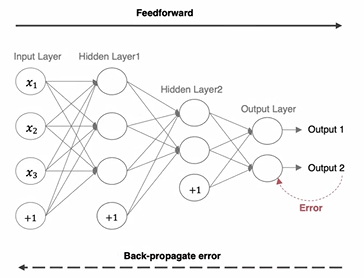

 在网络的训练过程中经过前向传播后得到的最终结果跟训练样本的真实值总是存在一定误差，这个误差便是损失函数。想要减小这个误差，就用损失函数 ERROR，从后往前，依次求各个参数的偏导，这就是反向传播（Back Propagation）。

### 2.1 链式法则

反向传播算法是利用链式法则进行梯度求解及权重更新的。对于复杂的复合函数，我们将其拆分为一系列的加减乘除或指数，对数，三角函数等初等函数，通过链式法则完成复合函数的求导。为简单起见，这里以一个神经网络中常见的复合函数的例子来说明这个过程。复合函数 $f(x)$ 为：

$$f(x) = \frac{1}{1 + e^{-(wx+b)}}$$

其参数为权重 $w$、$b$。我们需要求关于 $w$ 和 $b$ 的偏导，然后应用梯度下降公式就可以更新参数。

我们将复合函数分解为一系列的初等函数导数相乘的形式：

| 函数 | 导数 | |
| :--- | :--- | :--- |
| $h_1 = x \times w$ | $\frac{\partial h_1}{\partial w} = x$ | $\frac{\partial h_1}{\partial x} = w$ |
| $h_2 = h_1 + b$ | $\frac{\partial h_2}{\partial h_1} = 1$ | $\frac{\partial h_2}{\partial b} = 1$ |
| $h_3 = h_2 \times -1$ | $\frac{\partial h_3}{\partial h_2} = -1$ | |
| $h_4 = \exp(h_3)$ | $\frac{\partial h_4}{\partial h_3} = \exp(h_3)$ | |
| $h_5 = h_4 + 1$ | $\frac{\partial h_5}{\partial h_4} = 1$ | |
| $h_6 = 1/h_5$ | $\frac{\partial h_6}{\partial h_5} = -\frac{1}{h_5^2}$ | |

整个复合函数 $f(x; w, b)$ 关于参数 $w$ 和 $b$ 的导数可以通过 $f(x; w, b)$ 与参数 $w$ 和 $b$ 之间路径上所有的导数连乘来得到，即：

$$\frac{\partial f(x; w, b)}{\partial w} = \frac{\partial f(x; w, b)}{\partial h_6} \frac{\partial h_6}{\partial h_5} \frac{\partial h_5}{\partial h_4} \frac{\partial h_4}{\partial h_3} \frac{\partial h_3}{\partial h_2} \frac{\partial h_2}{\partial h_1} \frac{\partial h_1}{\partial w},$$
$$\frac{\partial f(x; w, b)}{\partial b} = \frac{\partial f(x; w, b)}{\partial h_6} \frac{\partial h_6}{\partial h_5} \frac{\partial h_5}{\partial h_4} \frac{\partial h_4}{\partial h_3} \frac{\partial h_3}{\partial h_2} \frac{\partial h_2}{\partial b}.$$

以 $w$ 为例，当 $x = 1, w = 0, b = 0$ 时，可以得到：

$$\left. \frac{\partial f(x; w, b)}{\partial w} \right|_{x=1, w=0, b=0} = \frac{\partial f(x; w, b)}{\partial h_6} \frac{\partial h_6}{\partial h_5} \frac{\partial h_5}{\partial h_4} \frac{\partial h_4}{\partial h_3} \frac{\partial h_3}{\partial h_2} \frac{\partial h_2}{\partial h_1} \frac{\partial h_1}{\partial w}$$
$$= 1 \times -0.25 \times 1 \times 1 \times -1 \times 1 \times 1$$
$$= 0.25.$$

常用函数的导数：

| 函数 | 导数 |
| :--- | :--- |
| $f(a) = a^2$ | $2a$ |
| $f(a) = a^3$ | $3a^2$ |
| $f(a) = \ln(a)$ | $\frac{1}{a}$ |
| $f(a) = e^a$ | $e^a$ |
| $\sigma(z) = \frac{1}{1 + e^{-z}}$ | $\sigma(z)(1 - \sigma(z))$ |
| $g(z) = \tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$ | $1 - (\tanh(z))^2 = 1 - (g(z))^2$ |

注：sigmoid 的导数计算

$$\sigma(x) = \frac{1}{1 + e^{-x}} \rightarrow \frac{d\sigma(x)}{dx} = \frac{e^{-x}}{(1 + e^{-x})^2} = \left( \frac{1 + e^{-x} - 1}{1 + e^{-x}} \right) \left( \frac{1}{1 + e^{-x}} \right) = (1 - \sigma(x))\sigma(x)$$

## 2.2 反向传播算法

* **BP (Back Propagation) 算法也叫做误差反向传播算法**，它用于求解模型的参数梯度，从而使用梯度下降法来更新网络参数。它的基本工作流程如下：
* **1**：通过正向传播得到误差，所谓正向传播指的是数据从输入到输出层，经过层层计算得到预测值，并利用损失函数得到预测值和真实值之间的误差。
* **2**：通过反向传播把误差传递给模型的参数，从而对网络参数进行适当的调整，缩小预测值和真实值之间的误差。
* **3**：反向传播算法是利用链式法则进行梯度求解，然后进行参数更新。对于复杂的复合函数，我们将其拆分为一系列的加减乘除或指数，对数，三角函数等初等函数，通过链式法则完成复合函数的求导。
* 下面我们使用代码构建上面的网络，并进行一次正向传播和反向传播。

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim


class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        self.linear1 = nn.Linear(2, 2)
        self.linear2 = nn.Linear(2, 2)

        # 网络参数初始化
        self.linear1.weight.data = torch.tensor([[0.15, 0.20], [0.25, 0.30]])
        self.linear2.weight.data = torch.tensor([[0.40, 0.45], [0.50, 0.55]])
        self.linear1.bias.data = torch.tensor([0.35, 0.35])
        self.linear2.bias.data = torch.tensor([0.60, 0.60])

    def forward(self, x):
        x = self.linear1(x)
        x = torch.sigmoid(x)
        x = self.linear2(x)
        x = torch.sigmoid(x)

        return x


if __name__ == '__main__':
    inputs = torch.tensor([[0.05, 0.10]])
    target = torch.tensor([[0.01, 0.99]])
    
    # 获得网络输出值
    net = Net()
    output = net(inputs)
    # print(output)  # tensor([[0.7514, 0.7729]], grad_fn=<SigmoidBackward>)

    # 计算误差
    loss = torch.sum((output - target) ** 2) / 2
    # print(loss)  # tensor(0.2984, grad_fn=<DivBackward0>)

    # 优化方法
    optimizer = optim.SGD(net.parameters(), lr=0.5)

    # 梯度清零
    optimizer.zero_grad()

    # 反向传播
    loss.backward()

    # 打印 w5、w7、w1 的梯度值
    print(net.linear1.weight.grad.data)
    # tensor([[0.0004, 0.0009],
    #         [0.0005, 0.0010]])

    print(net.linear2.weight.grad.data)
    # tensor([[ 0.0822,  0.0827],
    #         [-0.0226, -0.0227]])

    # 打印网络参数
    optimizer.step()
    print(net.state_dict())
    # OrderedDict([('linear1.weight', tensor([[0.1498, 0.1996], [0.2498, 0.2995]])),
    #              ('linear1.bias', tensor([0.3456, 0.3450])),
    #              ('linear2.weight', tensor([[0.3589, 0.4087], [0.5113, 0.5614]])),
    #              ('linear2.bias', tensor([0.5308, 0.6190]))])

tensor([[0.0004, 0.0009],
        [0.0005, 0.0010]])
tensor([[ 0.0822,  0.0827],
        [-0.0226, -0.0227]])
OrderedDict({'linear1.weight': tensor([[0.1498, 0.1996],
        [0.2498, 0.2995]]), 'linear1.bias': tensor([0.3456, 0.3450]), 'linear2.weight': tensor([[0.3589, 0.4087],
        [0.5113, 0.5614]]), 'linear2.bias': tensor([0.5308, 0.6190])})
